<a href="https://colab.research.google.com/github/tarak-thakore/ml-basics/blob/main/Math_Func_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [128]:
import torch
from torch import nn
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import math
import numpy as np
import time as time
from datetime import datetime

In [129]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [130]:
# random number seed for reproducibility
torch.manual_seed(2126)

In [131]:
# Utility functions - replace these with some built-in library functions

def standardize(data, mean, std):
    return (data - mean) / std

def destandardize(data,mean,std):
    return data*std + mean

def normalize(data,min,max):
    return (data-min)/(max-min)

def classification_accuracy(outputs,labels):
  _,predicted = torch.max(outputs,1)
  correct = (predicted == labels).sum().item()
  print(correct,labels.size(0))
  return correct/labels.size(0)

def accuracy_fn(y_true,y_pred):

    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred)) *100
    #print(correct,len(y_pred))
    return acc

def Plot_TrainData_Circle(X,y,plottitle):
  fig, ax = plt.subplots()
  #X = ds.x_data
  #y = ds.t_data
  ax.scatter(x=X[:,0],y=X[:,1], c=y, cmap=plt.cm.RdYlBu)

  # Draw a circle of radius 1 at (0,0)
  circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--')
  ax.add_artist(circle)

  ax.set_aspect('equal', adjustable='box') # Ensure the circle looks like a circle
  plt.title(plottitle)
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.show()


In [132]:
'''
target:
0 - outside the circle
1 - inside the circle

In this example, the distribution of data is highly asymmetric between two classes.
Despite that, the classification efficiency comes out be high, around 95%.

'''

class DataGenerator_Circle(Dataset):

  def __init__(self,n=1000, train_fraction=0.8):

    self.n = n
    self.num_train = int(train_fraction*self.n)
    self.num_val = self.n - self.num_train

    # Generate initial x and y values that will serve as coordinates
    x_coords_base = torch.distributions.uniform.Uniform(-1,1).sample([self.n,1])
    y_coords_base = torch.distributions.uniform.Uniform(-1,1).sample([self.n,1])

    # Calculate the radius from the noisy coordinates (this is our target 'y')
    self.r_data = torch.sqrt(x_coords_base**2 + y_coords_base**2)

    # Combine x_coords_base and y_coords_base into a single tensor for input 'x'
    # The input features will be a 2D tensor [x_coord, y_coord]
    self.x_data = torch.cat((x_coords_base, y_coords_base), dim=1)
    self.datadim = self.x_data.shape[1] # This will be 2

    # Calculate the new target variable 't': True if r <= 1, False otherwise
    self.t_data = (self.r_data <= 1).float() # Convert boolean to float (0.0 or 1.0)

    # data standardization stats for input features (x_data)
    self.mean_x = self.x_data.mean(dim=0)
    self.std_x = self.x_data.std(dim=0)
    # data standardization stats for target output (r_data)
    self.mean_r = self.r_data.mean()
    self.std_r = self.r_data.std()

    # data normalization stats for input features (x_data)
    self.min_x = self.x_data.min(dim=0).values
    self.max_x = self.x_data.max(dim=0).values
    # data normalization stats for target output (r_data)
    self.min_r = self.r_data.min()
    self.max_r = self.r_data.max()

  def __len__(self):
    return self.n

  def __getitem__(self, idx):
      x, r, t = self.x_data[idx], self.r_data[idx], self.t_data[idx]
      #x = standardize(x, self.mean_x, self.std_x)
      # do not standardize r if it's already in [-1,1], for example, in r=sin(x)
      #r = standardize(r, self.mean_r, self.std_r)

      #x = normalize(x, self.min_x, self.max_x)
      #r = normalize(r, self.min_x, self.max_x)

      return x,r,t

  def __str__(self):
    return f"I am a non-linear dataset with radius as target from (x,y) coordinates."


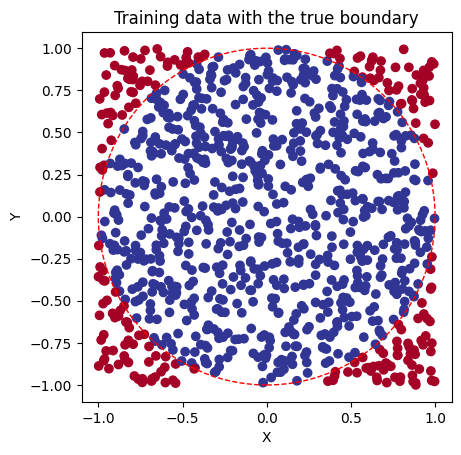

800 200


'\nfor i, batch in enumerate(dataloader_train):\n    print(type(batch),len(batch))\n    print(i, batch[0],batch[1])\n    break\n'

In [133]:
#ds = DataGenerator_Linear(torch.tensor([2.0]),torch.tensor([1.0]))
ds = DataGenerator_Circle()

# Plot training data
Plot_TrainData_Circle(ds.x_data,ds.t_data,plottitle='Training data with the true boundary')

train_ds, val_ds = torch.utils.data.random_split(ds,[ds.num_train,ds.num_val])
print(len(train_ds),len(val_ds))


# Create a DataLoader
dataloader_train= DataLoader(train_ds, batch_size=32, shuffle=True)
dataloader_val = DataLoader(val_ds, batch_size=32, shuffle=False)

# summary writer
writer = SummaryWriter('runs/mathfunc_fit_new')

#print(ds.x[:5,:],ds.y[:5])

'''
for i, batch in enumerate(dataloader_train):
    print(type(batch),len(batch))
    print(i, batch[0],batch[1])
    break
'''

In [134]:
class NN_Classification1(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
      nn.Linear(2,5),
      nn.ReLU(),
      nn.Linear(5,5),
      nn.ReLU(),
      nn.Linear(5,1),
    )

  def forward(self,X):
    return self.net(X)


In [135]:
model = NN_Classification1().to(device)
#model = NN_Regression2(lr = 0.01).to(device)
print(model)
# Define loss function and optimizer
#criterion = nn.CrossEntropyLoss()
#criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss() # sigmoid built-in
#optimizer = optim.SGD(model.parameters(), lr=0.01,  weight_decay=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, 0.99)

# Early Stopping Parameters
patience = 10 # Number of epochs to wait for improvement
min_delta = 0.0001 # Minimum change in the monitored metric to be considered an improvement

best_val_loss = float('inf') # Initialize with a very high value
epochs_no_improve = 0 # Counter for epochs without improvement
early_stop_triggered = False


NN_Classification1(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=1, bias=True)
  )
)


In [136]:
# play with the training data and the network output manually
x_test = ds.x_data[20:30,:]
r_test = ds.r_data[20:30]
t_test = ds.t_data[20:30]
#print(x_test)
#print(r_test)
print('true label',t_test.squeeze())

y_test = model(x_test.to(device))
print('raw pred',y_test.squeeze())
y_test_prob = torch.sigmoid(y_test)
print('pred prob',y_test_prob.squeeze())
y_test_pred = (y_test_prob > 0.5).float()
print('pred label',y_test_pred.squeeze())
#print('accuracy = ',classification_accuracy(y_test_pred,t_test))
print('accuracy = ',accuracy_fn(t_test,y_test_pred))

true label tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 1.])
raw pred tensor([-0.1158, -0.1357, -0.1106, -0.0947, -0.1036, -0.0993, -0.1290, -0.0870,
        -0.1191, -0.1364], grad_fn=<SqueezeBackward0>)
pred prob tensor([0.4711, 0.4661, 0.4724, 0.4764, 0.4741, 0.4752, 0.4678, 0.4783, 0.4703,
        0.4659], grad_fn=<SqueezeBackward0>)
pred label tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
accuracy =  20.0


In [137]:
# Training loop
num_epochs = 2000
batch_size = 32
start_t = time.time()

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for i,(x,r,y) in enumerate(dataloader_train):
        # Forward pass
        x,y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)

        # reset gradients
        optimizer.zero_grad()

        # backward pass
        loss.backward()
        # update weights
        optimizer.step()

        train_loss += loss.item()* x.size(0)

    avg_train_loss = train_loss / len(dataloader_train.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for i,(x,r,y) in enumerate(dataloader_val):
            x,y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item() * x.size(0)

    avg_val_loss = val_loss / len(dataloader_val.dataset)

    # Log both training and validation losses together
    writer.add_scalars('Overall Loss', {'Training': avg_train_loss,
                                        'Validation': avg_val_loss}, epoch)

    if (epoch+1)%10 == 0 :
      print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_train_loss:.5f}, \
        Validation Loss: {avg_val_loss:.5f}')

    # --- Early Stopping Logic ---
    if avg_val_loss < best_val_loss - min_delta: # Check for significant improvement
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save the best model
        #torch.save(model.state_dict(), best_model_path)
        torch.save(model.state_dict(),'best_model.pth')
        #print(" -> Validation loss improved. Saving model.")
    else:
        epochs_no_improve += 1
        #print(f" -> No improvement for {epochs_no_improve} epochs.")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs due to no improvement for {patience} epochs.")
            early_stop_triggered = True
            break # Exit the training loop

    if not early_stop_triggered:
        #print("\nTraining completed all epochs without early stopping.")
        pass
    else:
        print("\nTraining stopped early.")

end_t = time.time()
print('Training Complete!')
print(f'Training time: {end_t-start_t:.4f} sec')
writer.close()

Epoch [10/2000], Training Loss: 0.55462,         Validation Loss: 0.57613
Epoch [20/2000], Training Loss: 0.49705,         Validation Loss: 0.55621
Epoch [30/2000], Training Loss: 0.47464,         Validation Loss: 0.54855
Epoch [40/2000], Training Loss: 0.44949,         Validation Loss: 0.52600
Epoch [50/2000], Training Loss: 0.42090,         Validation Loss: 0.49852
Epoch [60/2000], Training Loss: 0.39337,         Validation Loss: 0.47402
Epoch [70/2000], Training Loss: 0.36918,         Validation Loss: 0.45161
Epoch [80/2000], Training Loss: 0.34987,         Validation Loss: 0.43488
Epoch [90/2000], Training Loss: 0.33220,         Validation Loss: 0.41350
Epoch [100/2000], Training Loss: 0.31595,         Validation Loss: 0.39783
Epoch [110/2000], Training Loss: 0.29663,         Validation Loss: 0.37426
Epoch [120/2000], Training Loss: 0.27693,         Validation Loss: 0.34801
Epoch [130/2000], Training Loss: 0.25289,         Validation Loss: 0.31855
Epoch [140/2000], Training Loss: 0

In [138]:
model.eval()

NN_Classification1(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=1, bias=True)
  )
)

test accuracy = 98.0%


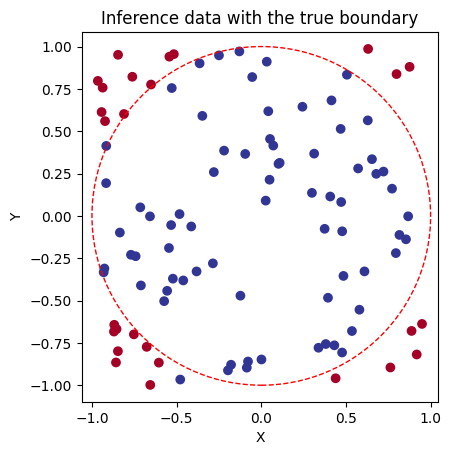

In [139]:
x_new = torch.distributions.uniform.Uniform(-1,1).sample([100,2])
r_new = torch.sqrt(x_new[:,0]**2 + x_new[:,1]**2)
t_new = (r_new <= 1).float()
with torch.inference_mode():
  y_new = model(x_new)
  y_new_labels = torch.round(torch.sigmoid(y_new)).squeeze(dim=1)

#print('test labels',t_new)
#print('test pred',y_new_labels)
print(f'test accuracy = {accuracy_fn(t_new,y_new_labels)}%')


# TODO : implement color scheme to visualize correctness of classification.
Plot_TrainData_Circle(x_new,y_new_labels,plottitle='Inference data with the true boundary')